# Figure Generation

This notebook is configured for the final reported runs.
Each figure is generated in its own code cell and exported into `Report/Figures/`.

In [9]:
from pathlib import Path
import csv
import math

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (
            (candidate / "Train").exists()
            and (candidate / "Reference").exists()
            and (candidate / "Report").exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()
FIG_ROOT = REPO_ROOT / "Report" / "Figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "smrt_run_dir": "Train/Results/DeepGCNRT/SMRT/20260324_103037_097_e9b75031",
    "riken_run_dir": "Train/Results/DeepGCNRT/RIKENMONA/20260415_073928_305_f0cb86ba",
    "mini_summary_paths": {
        "Cao_HILIC_116": "Train/Results/DeepGCNRT/MiniDatasets/Cao_HILIC_116/summary.csv",
        "Eawag_XBridgeC18_364": "Train/Results/DeepGCNRT/MiniDatasets/Eawag_XBridgeC18_364/summary.csv",
        "FEM_lipids_72": "Train/Results/DeepGCNRT/MiniDatasets/FEM_lipids_72/summary.csv",
        "FEM_long_412": "Train/Results/DeepGCNRT/MiniDatasets/FEM_long_412/summary.csv",
        "FEM_short_73": "Train/Results/DeepGCNRT/MiniDatasets/FEM_short_73/summary.csv",
        "IPB_Halle_82": "Train/Results/DeepGCNRT/MiniDatasets/IPB_Halle_82/summary.csv",
        "LIFE_new_184": "Train/Results/DeepGCNRT/MiniDatasets/LIFE_new_184/summary.csv",
        "LIFE_old_194": "Train/Results/DeepGCNRT/MiniDatasets/LIFE_old_194/summary.csv",
        "MTBLS87_147": "Train/Results/DeepGCNRT/MiniDatasets/MTBLS87_147/summary.csv",
        "UniToyama_Atlantis_143": "Train/Results/DeepGCNRT/MiniDatasets/UniToyama_Atlantis_143/summary.csv",
    },
}

SMRT_BASELINE_MAE = {
    "GCN (paper)": 29.40,
    "DNNpwa (paper)": 39.62,
    "GNN-RT (paper)": 39.87,
    "DeepGCN-RT (paper)": 26.55,
}

PAPER_RIKEN_MAE = {
    "Paper TL\n(original split)": 21.45,
    "Paper TL\n(deduplicated)": 24.43,
}

OFFICIAL_TRANSFER_MAE = {
    "Eawag_XBridgeC18_364": 45.97,
    "FEM_lipids_72": 74.48,
    "FEM_long_412": 110.89,
    "IPB_Halle_82": 21.20,
    "LIFE_new_184": 18.13,
    "LIFE_old_194": 12.07,
    "UniToyama_Atlantis_143": 50.03,
    "Cao_HILIC_116": 67.64,
    "FEM_short_73": 77.70,
    "MTBLS87_147": 79.74,
}

LABELS = {
    "Eawag_XBridgeC18_364": "Eawag",
    "FEM_lipids_72": "FEM lipids",
    "FEM_long_412": "FEM long",
    "IPB_Halle_82": "IPB Halle",
    "LIFE_new_184": "LIFE new",
    "LIFE_old_194": "LIFE old",
    "UniToyama_Atlantis_143": "UniToyama",
    "Cao_HILIC_116": "Cao HILIC",
    "FEM_short_73": "FEM short",
    "MTBLS87_147": "MTBLS87",
}


def normalize_path(value):
    if value in (None, "", []):
        return None
    path = Path(value)
    return path if path.is_absolute() else REPO_ROOT / path


def read_csv_rows(path):
    with Path(path).open(newline="") as f:
        return list(csv.DictReader(f))


def read_predictions(path):
    rows = read_csv_rows(path)
    y = [float(row["target"]) for row in rows]
    p = [float(row["prediction"]) for row in rows]
    return y, p


def compute_metrics(y, p):
    n = len(y)
    abs_err = [abs(a - b) for a, b in zip(y, p)]
    sq_err = [(a - b) ** 2 for a, b in zip(y, p)]
    y_mean = sum(y) / n
    denom = sum((value - y_mean) ** 2 for value in y)
    abs_sorted = sorted(abs_err)
    medae = (
        abs_sorted[n // 2]
        if n % 2
        else 0.5 * (abs_sorted[n // 2 - 1] + abs_sorted[n // 2])
    )
    mse = sum(sq_err) / n
    return {
        "n": n,
        "mae": sum(abs_err) / n,
        "medae": medae,
        "mape": sum(abs(a - b) / max(abs(a), 1e-8) for a, b in zip(y, p)) / n,
        "mse": mse,
        "rmse": math.sqrt(mse),
        "r2": 0.0 if denom <= 0 else 1.0 - sum(sq_err) / denom,
    }


def run_dir_metrics(run_dir):
    run_dir = normalize_path(run_dir)
    if run_dir is None:
        return None
    pred_path = run_dir / "test_predictions.csv"
    if not pred_path.exists():
        return None
    y, p = read_predictions(pred_path)
    metrics = compute_metrics(y, p)
    metrics["run_name"] = run_dir.name
    metrics["targets"] = y
    metrics["predictions"] = p
    return metrics


def load_summary_row(summary_path):
    summary_path = normalize_path(summary_path)
    if summary_path is None or not summary_path.exists():
        return None
    rows = read_csv_rows(summary_path)
    return rows[-1] if rows else None


def mini_metrics_from_summaries(summary_paths):
    records = []
    for dataset_name, summary_path in summary_paths.items():
        row = load_summary_row(summary_path)
        if row is None:
            continue
        result_dir = normalize_path(row.get("result_dir"))
        pred_path = None if result_dir is None else result_dir / "test_predictions.csv"
        test_size = None
        if pred_path is not None and pred_path.exists():
            test_size = len(read_predictions(pred_path)[0])
        our_mae = float(row["test_mae"]) if row.get("test_mae") else None
        official_mae = OFFICIAL_TRANSFER_MAE.get(dataset_name)
        records.append(
            {
                "dataset": dataset_name,
                "label": LABELS.get(dataset_name, dataset_name),
                "official_mae": official_mae,
                "our_mae": our_mae,
                "mae_gap": (
                    None
                    if our_mae is None or official_mae is None
                    else our_mae - official_mae
                ),
                "mean_test_size": test_size,
            }
        )
    return records

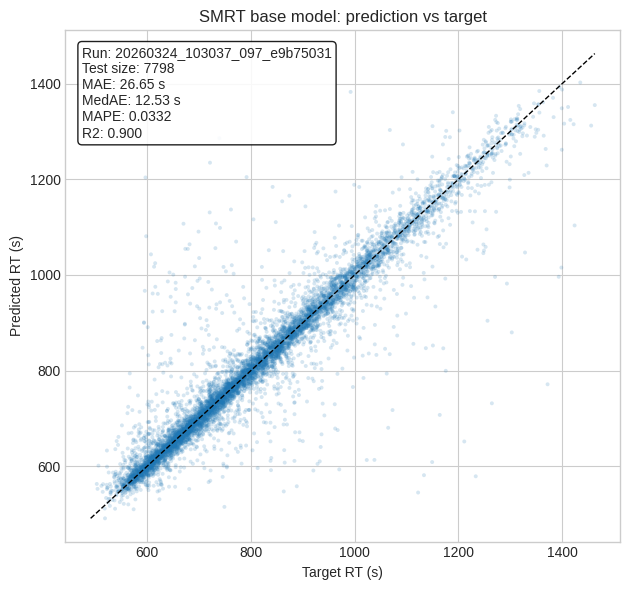

In [10]:
out_path = FIG_ROOT / "smrt_base_scatter_report.png"
smrt = run_dir_metrics(CONFIG["smrt_run_dir"])

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(
    smrt["targets"],
    smrt["predictions"],
    s=8,
    alpha=0.18,
    color="#1f77b4",
    edgecolors="none",
)
lo = min(min(smrt["targets"]), min(smrt["predictions"]))
hi = max(max(smrt["targets"]), max(smrt["predictions"]))
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
ax.set_title("SMRT base model: prediction vs target")
ax.set_xlabel("Target RT (s)")
ax.set_ylabel("Predicted RT (s)")
summary = (
    f"Run: {smrt['run_name']}\n"
    f"Test size: {smrt['n']}\n"
    f"MAE: {smrt['mae']:.2f} s\n"
    f"MedAE: {smrt['medae']:.2f} s\n"
    f"MAPE: {smrt['mape']:.4f}\n"
    f"R2: {smrt['r2']:.3f}"
)
ax.text(
    0.03,
    0.97,
    summary,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.88),
)
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

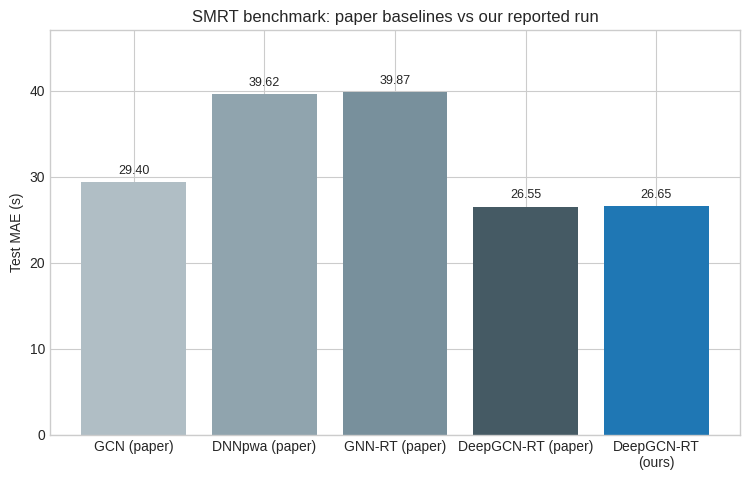

In [11]:
out_path = FIG_ROOT / "smrt_mae_comparison_report.png"
smrt = run_dir_metrics(CONFIG["smrt_run_dir"])

labels = list(SMRT_BASELINE_MAE) + ["DeepGCN-RT\n(ours)"]
values = list(SMRT_BASELINE_MAE.values()) + [smrt["mae"]]
colors = ["#b0bec5", "#90a4ae", "#78909c", "#455a64", "#1f77b4"]
fig, ax = plt.subplots(figsize=(7.6, 4.9))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Test MAE (s)")
ax.set_title("SMRT benchmark: paper baselines vs our reported run")
ax.set_ylim(0, max(values) * 1.18)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.6,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

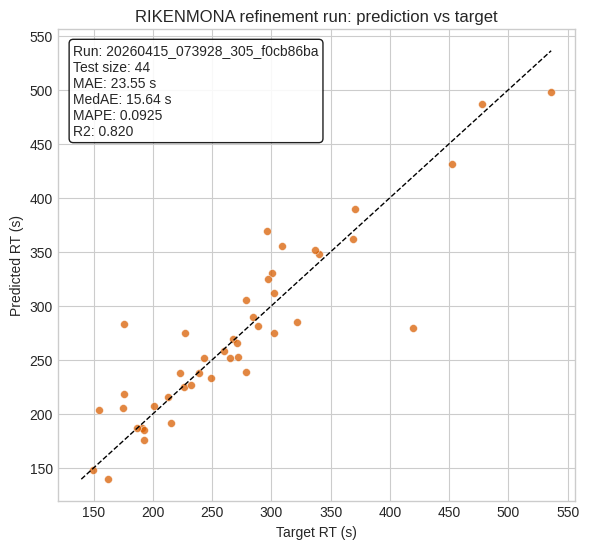

In [12]:
out_path = FIG_ROOT / "riken_refined_scatter_report.png"
riken = run_dir_metrics(CONFIG["riken_run_dir"])

fig, ax = plt.subplots(figsize=(6.0, 5.6))
ax.scatter(
    riken["targets"],
    riken["predictions"],
    s=32,
    alpha=0.75,
    color="#d95f02",
    edgecolors="white",
    linewidth=0.4,
)
lo = min(min(riken["targets"]), min(riken["predictions"]))
hi = max(max(riken["targets"]), max(riken["predictions"]))
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
ax.set_title("RIKENMONA refinement run: prediction vs target")
ax.set_xlabel("Target RT (s)")
ax.set_ylabel("Predicted RT (s)")
summary = (
    f"Run: {riken['run_name']}\n"
    f"Test size: {riken['n']}\n"
    f"MAE: {riken['mae']:.2f} s\n"
    f"MedAE: {riken['medae']:.2f} s\n"
    f"MAPE: {riken['mape']:.4f}\n"
    f"R2: {riken['r2']:.3f}"
)
ax.text(
    0.03,
    0.97,
    summary,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.88),
)
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

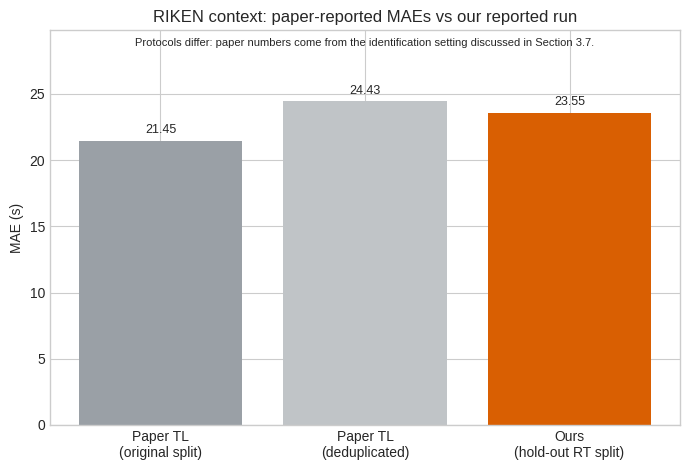

In [13]:
out_path = FIG_ROOT / "riken_mae_context_report.png"
riken = run_dir_metrics(CONFIG["riken_run_dir"])

labels = list(PAPER_RIKEN_MAE) + ["Ours\n(hold-out RT split)"]
values = list(PAPER_RIKEN_MAE.values()) + [riken["mae"]]
colors = ["#9aa0a6", "#c0c4c7", "#d95f02"]
fig, ax = plt.subplots(figsize=(7.0, 4.8))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("MAE (s)")
ax.set_title("RIKEN context: paper-reported MAEs vs our reported run")
ax.set_ylim(0, max(values) * 1.22)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.35,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.text(
    0.5,
    0.98,
    "Protocols differ: paper numbers come from the identification setting discussed in Section 3.7.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=8,
)
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

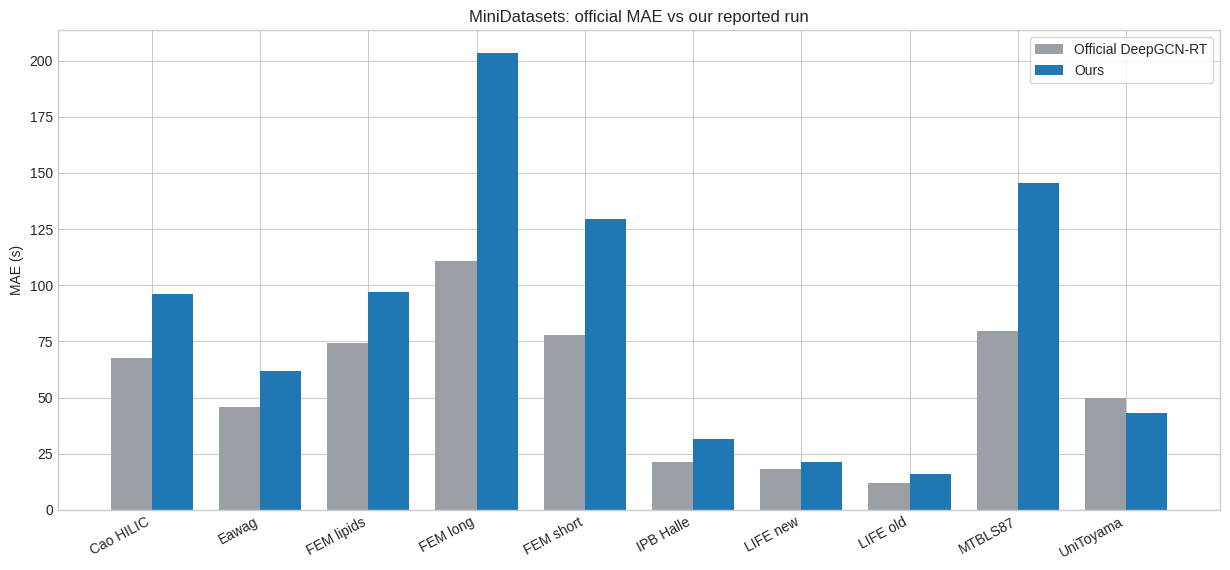

In [14]:
out_path = FIG_ROOT / "mini_all_mae_comparison.png"
records = mini_metrics_from_summaries(CONFIG["mini_summary_paths"])

labels = [item["label"] for item in records]
official = [item["official_mae"] for item in records]
ours = [item["our_mae"] for item in records]
positions = list(range(len(records)))
width = 0.38
fig, ax = plt.subplots(figsize=(12.4, 5.8))
ax.bar(
    [x - width / 2 for x in positions],
    official,
    width=width,
    color="#9aa0a6",
    label="Official DeepGCN-RT",
)
ax.bar(
    [x + width / 2 for x in positions],
    ours,
    width=width,
    color="#1f77b4",
    label="Ours",
)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=28, ha="right")
ax.set_ylabel("MAE (s)")
ax.set_title("MiniDatasets: official MAE vs our reported run")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

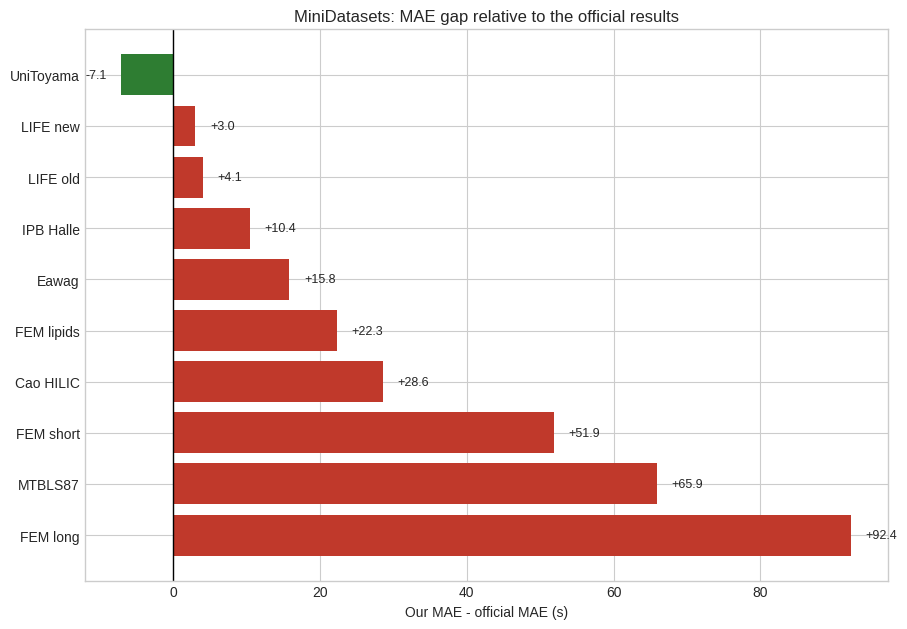

In [15]:
out_path = FIG_ROOT / "mini_mae_gap_sorted.png"
records = [
    item
    for item in mini_metrics_from_summaries(CONFIG["mini_summary_paths"])
    if item["mae_gap"] is not None
]

records = sorted(records, key=lambda item: item["mae_gap"], reverse=True)
labels = [item["label"] for item in records]
gaps = [item["mae_gap"] for item in records]
colors = ["#c0392b" if gap > 0 else "#2e7d32" for gap in gaps]
y = list(range(len(records)))
fig, ax = plt.subplots(figsize=(9.2, 6.4))
bars = ax.barh(y, gaps, color=colors)
ax.axvline(0.0, color="black", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Our MAE - official MAE (s)")
ax.set_title("MiniDatasets: MAE gap relative to the official results")
for yi, gap in zip(y, gaps):
    offset = 2.0 if gap >= 0 else -2.0
    ha = "left" if gap >= 0 else "right"
    ax.text(gap + offset, yi, f"{gap:+.1f}", va="center", ha=ha, fontsize=9)
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

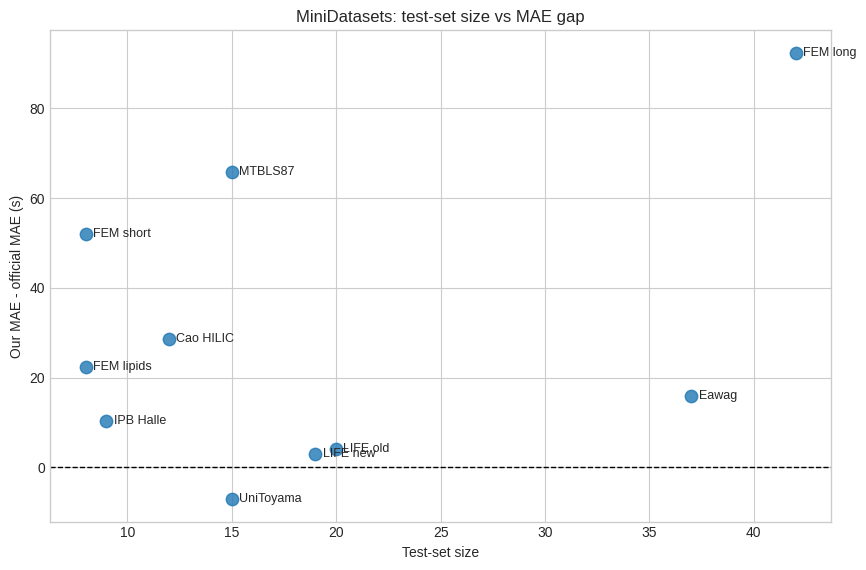

In [16]:
out_path = FIG_ROOT / "mini_test_size_vs_gap.png"
records = [
    item
    for item in mini_metrics_from_summaries(CONFIG["mini_summary_paths"])
    if item["mae_gap"] is not None and item["mean_test_size"] is not None
]

fig, ax = plt.subplots(figsize=(8.8, 5.8))
xs = [item["mean_test_size"] for item in records]
ys = [item["mae_gap"] for item in records]
ax.scatter(xs, ys, s=80, color="#1f77b4", marker="o", alpha=0.8)
for item in records:
    ax.text(
        item["mean_test_size"] + 0.35,
        item["mae_gap"],
        item["label"],
        fontsize=9,
        va="center",
    )
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("Test-set size")
ax.set_ylabel("Our MAE - official MAE (s)")
ax.set_title("MiniDatasets: test-set size vs MAE gap")
fig.tight_layout()
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()